**分类算法全流程实践**

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import os
# ── 数据准备 ──────────────────────────────────────────
custom_path = r"E:\home study\week2\sklearn_data"
os.environ['SCIKIT_LEARN_DATA'] = custom_path
cats = ['sci.med', 'talk.politics.guns', 'rec.sport.baseball', 'comp.graphics']
data = fetch_20newsgroups(subset='all', categories=cats, remove=('headers','footers','quotes'))
X_text, y = data.data, data.target

# ── 文本特征提取 ──────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=10000,   # 只保留词频最高的10000个词
    ngram_range=(1, 2),   # unigram + bigram
    sublinear_tf=True,    # 对TF取log，减少高频词影响
    min_df=3              # 至少出现3次才保留
)

X = vectorizer.fit_transform(X_text)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify保证分层采样
)

# ── 训练多个模型并对比 ────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
    'Random Forest': RandomForestClassifier(n_estimators=100, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100),
    'SVM (Linear)': SVC(kernel='linear', C=1.0, probability=True),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = classification_report(y_test, y_pred, output_dict=True)['macro avg']['f1-score']
    results[name] = f1
    print(f"{name}: F1 = {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=cats))
    print("─" * 60)

# ── 超参数搜索（GridSearchCV）────────────────────────
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5,
                    scoring='f1_macro', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print(f"最优参数: {grid.best_params_}, 最优F1: {grid.best_score_:.4f}")

Logistic Regression: F1 = 0.9098
                    precision    recall  f1-score   support

           sci.med       0.91      0.92      0.92       195
talk.politics.guns       0.87      0.94      0.91       199
rec.sport.baseball       0.92      0.85      0.88       198
     comp.graphics       0.93      0.93      0.93       182

          accuracy                           0.91       774
         macro avg       0.91      0.91      0.91       774
      weighted avg       0.91      0.91      0.91       774

────────────────────────────────────────────────────────────
Random Forest: F1 = 0.8403
                    precision    recall  f1-score   support

           sci.med       0.84      0.88      0.86       195
talk.politics.guns       0.80      0.91      0.85       199
rec.sport.baseball       0.80      0.74      0.77       198
     comp.graphics       0.94      0.83      0.88       182

          accuracy                           0.84       774
         macro avg       0.85     

**核心评估指标**

                    precision    recall  f1-score   support

           sci.med       0.94      0.90      0.92       195
talk.politics.guns       0.86      0.93      0.89       199
rec.sport.baseball       0.91      0.86      0.88       198
     comp.graphics       0.90      0.90      0.90       182

          accuracy                           0.90       774
         macro avg       0.90      0.90      0.90       774
      weighted avg       0.90      0.90      0.90       774

多分类Macro AUC (OVR): 0.9857


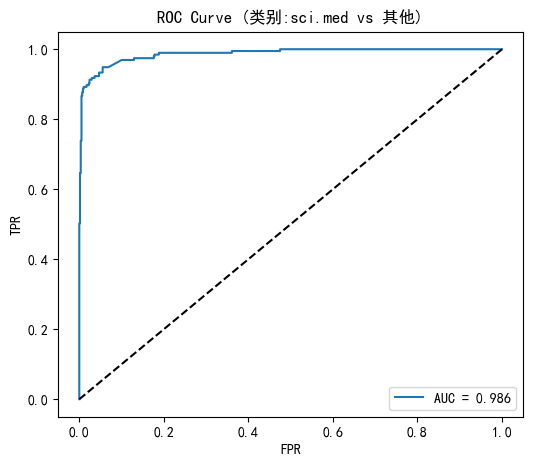

Macro 平均召回率: 0.8980


In [9]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve
)
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
# 配置中文字体
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
# 解决负号'-'显示方块问题
plt.rcParams["axes.unicode_minus"] = False

# 分类报告（包含P/R/F1，按类别和宏平均）
print(classification_report(y_test, y_pred, target_names=cats))

# ========== 多分类AUC修正写法 ==========
# predict_proba 输出 shape = [样本数, 4]，4列对应4个类别的预测概率
y_prob_all = model.predict_proba(X_test)

# 多分类AUC，选用一对多OVR方案，宏平均
auc = roc_auc_score(
    y_test, 
    y_prob_all,
    multi_class="ovr",
    average="macro"
)
print(f"多分类Macro AUC (OVR): {auc:.4f}")

# ROC曲线只能针对【单个二分类子任务】绘制，不能直接画4分类整体ROC
# 举例：单独拿第0类(sci.med) vs 其余所有类 画ROC
target_class_idx = 0
y_binary = (y_test == target_class_idx).astype(int)
y_prob_single = y_prob_all[:, target_class_idx]

fpr, tpr, _ = roc_curve(y_binary, y_prob_single)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.title(f'ROC Curve (类别:{cats[target_class_idx]} vs 其他)')
plt.show()

# 安全场景核心认知：Recall（召回率）最重要（漏检 >> 误检）
print(f"Macro 平均召回率: {recall_score(y_test, y_pred, average='macro'):.4f}")

**Pipeline：组合预处理和模型**

混淆矩阵：
 [[176   8   7   4]
 [  2 185   5   7]
 [  7  13 170   8]
 [  3  10   5 164]]


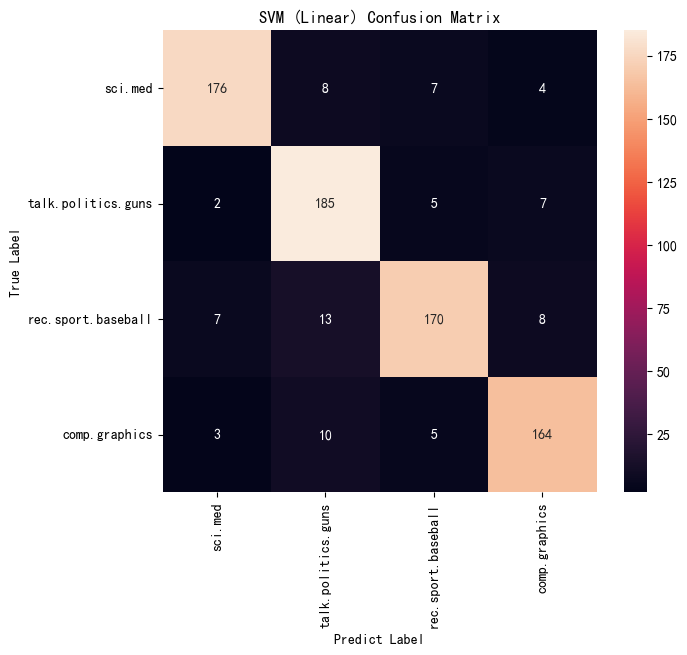

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 在单模型训练循环内，y_pred生成后添加
cm = confusion_matrix(y_test, y_pred)
print("混淆矩阵：\n", cm)

# 热力图可视化混淆矩阵
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=cats, yticklabels=cats)
plt.xlabel("Predict Label")
plt.ylabel("True Label")
plt.title(f"{name} Confusion Matrix")
plt.show()